# Draft

In [1]:
import os
from pathlib import Path

# Base project folder (adjust as you like)
BASE_DIR = Path.cwd() / "arctic_routing_paperA"
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

for p in [BASE_DIR, DATA_DIR, RAW_DIR, PROCESSED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Subfolders for different sources
SEAICE_DIR = RAW_DIR / "seaice_cmems"
BATHY_DIR = RAW_DIR / "bathymetry_gebco"
for p in [SEAICE_DIR, BATHY_DIR]:
    p.mkdir(parents=True, exist_ok=True)

BASE_DIR, DATA_DIR

(PosixPath('/Users/abdellamohamed/projects/phd/src/voyage_optimization/submission_3/notebooks/arctic_routing_paperA'),
 PosixPath('/Users/abdellamohamed/projects/phd/src/voyage_optimization/submission_3/notebooks/arctic_routing_paperA/data'))

In [2]:
# In a Jupyter notebook:
!pip install copernicusmarine xarray netCDF4 rasterio cdsapi

import xarray as xr
import numpy as np

In [4]:
import os
from pathlib import Path
import subprocess

USERNAME = "amohamed1"
PASSWORD = "568491103Seekaadam_"  # <- use your current Copernicus password here

# Path to Copernicus Marine credentials file (from the message you saw)
cred_path = Path.home() / ".copernicusmarine" / ".copernicusmarine-credentials"

# 1) Remove old credentials file if it exists
if cred_path.exists():
    print(f"Removing existing credentials file: {cred_path}")
    cred_path.unlink()

# 2) Run non-interactive login
result = subprocess.run(
    ["copernicusmarine", "login", "--username", USERNAME, "--password", PASSWORD],
    capture_output=True,
    text=True,
)

print("Return code:", result.returncode)
print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)

Removing existing credentials file: /Users/abdellamohamed/.copernicusmarine/.copernicusmarine-credentials
Return code: 0
STDOUT:
 
STDERR:
 INFO - 2025-12-02T09:45:30Z - Credentials file stored in /Users/abdellamohamed/.copernicusmarine/.copernicusmarine-credentials.



# 1. Donwload Sea ice reanalysis (Copernicus Marine)

In [5]:
# Cell 1 – define AOI + time range

from datetime import datetime

# Time range for first experiment
t_start = "2018-06-01T00:00:00"
t_end   = "2018-09-30T23:59:59"

# Geographic box (in geographic lat/lon, even though product is polar-projected)
lon_min, lon_max = -30.0, 200.0
lat_min, lat_max = 60.0, 90.0

seaice_outfile = SEAICE_DIR / "cmems_arc_seaice_2018_JJAS_subset.nc"
seaice_outfile

PosixPath('/Users/abdellamohamed/projects/phd/src/voyage_optimization/submission_3/notebooks/arctic_routing_paperA/data/raw/seaice_cmems/cmems_arc_seaice_2018_JJAS_subset.nc')

In [6]:
# Cell 2 – download with copernicusmarine.subset

import copernicusmarine

# IMPORTANT:
# - Make sure `copernicusmarine login` succeeded in your terminal before running this.
# - Adjust `variables` if the dataset uses slightly different names.
copernicusmarine.subset(
    dataset_id="cmems_mod_arc_phy_my_nextsim_P1D-m",
    variables=["siconc", "sithick"],  # sea ice concentration, thickness
    minimum_longitude=lon_min,
    maximum_longitude=lon_max,
    minimum_latitude=lat_min,
    maximum_latitude=lat_max,
    start_datetime=t_start,
    end_datetime=t_end,
    output_filename=str(seaice_outfile),
)

seaice_outfile

INFO - 2025-12-02T09:47:55Z - Selected dataset version: "202411"
INFO - 2025-12-02T09:47:55Z - Selected dataset part: "default"
INFO - 2025-12-02T09:48:04Z - Starting download. Please wait...


  0%|          | 0/1042 [00:00<?, ?it/s]

INFO - 2025-12-02T10:08:18Z - Successfully downloaded to /Users/abdellamohamed/projects/phd/src/voyage_optimization/submission_3/notebooks/arctic_routing_paperA/data/raw/seaice_cmems/cmems_arc_seaice_2018_JJAS_subset.nc


PosixPath('/Users/abdellamohamed/projects/phd/src/voyage_optimization/submission_3/notebooks/arctic_routing_paperA/data/raw/seaice_cmems/cmems_arc_seaice_2018_JJAS_subset.nc')

In [8]:
# Cell 3 – quick sanity check

ds_ice = xr.open_dataset(seaice_outfile)
ds_ice

<xarray.Dataset> Size: 15GB
Dimensions:    (time: 122, latitude: 1000, longitude: 7667)
Coordinates:
  * latitude   (latitude) float64 8kB 60.0 60.03 60.06 ... 89.91 89.94 89.97
  * time       (time) datetime64[ns] 976B 2018-06-01 2018-06-02 ... 2018-09-30
  * longitude  (longitude) float64 61kB -30.0 -29.97 -29.94 ... 200.0 200.0
Data variables:
    siconc     (time, latitude, longitude) float64 7GB ...
    sithick    (time, latitude, longitude) float64 7GB ...
Attributes:
    contact:                   servicedesk.cmems@mercator-ocean.eu
    institution:               NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:                    neXtSIM model fields
    title:                     Arctic sea ice reanalysis
    references:                https://marine.copernicus.eu/
    credit:                    E.U. Copernicus Marine Service Information (CM...
    Conventions:               CF-1.6
    copernicusmarine_version:  2.2.5

# 2. Bathymetry (GEBCO / IBCAO)

In [10]:
BATHY_DIR

PosixPath('/Users/abdellamohamed/projects/phd/src/voyage_optimization/submission_3/notebooks/arctic_routing_paperA/data/raw/bathymetry_gebco')

In [11]:
# Cell 4 – open and crop GEBCO

import xarray as xr

gebco_file = BATHY_DIR / "gebco_2024_sub_ice_topo" / "GEBCO_2024_sub_ice_topo.nc"  # rename if different
gebco = xr.open_dataset(gebco_file)

gebco

<xarray.Dataset> Size: 7GB
Dimensions:    (lon: 86400, lat: 43200)
Coordinates:
  * lon        (lon) float64 691kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * lat        (lat) float64 346kB -90.0 -89.99 -89.99 ... 89.99 89.99 90.0
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) int16 7GB ...
Attributes: (12/36)
    title:                           The GEBCO_2024 Grid - a continuous terra...
    summary:                         The GEBCO_2024 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    references:                      DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    node_offset:                     1.0

In [13]:
ds_global= gebco

In [14]:
# Cell 2 – define our routing corridor & subset

# Target corridor for the paper
LAT_MIN, LAT_MAX = 40.0, 85.0
LON_MIN, LON_MAX = -20.0, 180.0

# Handle 0–360 longitude in GEBCO
lons_global = ds_global["lon"].values
lon_max_val = float(lons_global.max())

if lon_max_val > 180:  # typical GEBCO case: 0..360
    def wrap_lon(lon):
        lon_arr = np.array(lon)
        return np.mod(lon_arr, 360.0)

    lon_min_wrapped = wrap_lon(LON_MIN)
    lon_max_wrapped = wrap_lon(LON_MAX)
    
    ds_sub = ds_global.sel(
        lon=slice(lon_min_wrapped, lon_max_wrapped),
        lat=slice(LAT_MIN, LAT_MAX)
    )
else:
    # Already -180..180
    ds_sub = ds_global.sel(
        lon=slice(LON_MIN, LON_MAX),
        lat=slice(LAT_MIN, LAT_MAX)
    )

ds_sub

<xarray.Dataset> Size: 1GB
Dimensions:    (lon: 48000, lat: 10800)
Coordinates:
  * lon        (lon) float64 384kB -20.0 -19.99 -19.99 ... 180.0 180.0 180.0
  * lat        (lat) float64 86kB 40.0 40.01 40.01 40.01 ... 84.99 84.99 85.0
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) int16 1GB ...
Attributes: (12/36)
    title:                           The GEBCO_2024 Grid - a continuous terra...
    summary:                         The GEBCO_2024 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    references:                      DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    node_offset:                     1.0

In [15]:
# Cell 3 – save the corridor subset so we never touch the big file again

corridor_bathy_file = BATHY_DIR / "GEBCO_2024_arctic_corridor.nc"
ds_sub.to_netcdf(corridor_bathy_file)
corridor_bathy_file

PosixPath('/Users/abdellamohamed/projects/phd/src/voyage_optimization/submission_3/notebooks/arctic_routing_paperA/data/raw/bathymetry_gebco/GEBCO_2024_arctic_corridor.nc')

In [16]:
# Cell 4 – create masks

ds_bathy = xr.open_dataset(corridor_bathy_file)

# Determine depth variable name
if "elevation" in ds_bathy:
    depth_raw = ds_bathy["elevation"]
elif "z" in ds_bathy:
    depth_raw = ds_bathy["z"]
else:
    raise ValueError("No 'elevation' or 'z' variable found in GEBCO dataset.")

# Define your representative ship draft and safety margin
ship_draft = 12.0        # m, adjust later if needed
min_under_keel = 20.0    # m safety margin
min_depth_allowed = -(ship_draft + min_under_keel)  # e.g. -32 m

land_mask = depth_raw >= 0.0
shallow_mask = (depth_raw < 0.0) & (depth_raw > min_depth_allowed)
deep_water_mask = depth_raw <= min_depth_allowed

ds_bathy_masks = xr.Dataset(
    {
        "depth": depth_raw,
        "is_land": land_mask,
        "is_shallow": shallow_mask,
        "is_deep_water": deep_water_mask,
    }
)

bathy_mask_outfile = PROCESSED_DIR / "bathy_masks_GEBCO2024_arctic_corridor.nc"
ds_bathy_masks.to_netcdf(bathy_mask_outfile)
bathy_mask_outfile

RuntimeError: NetCDF: HDF error

In [21]:
ds_bathy_masks

<xarray.Dataset> Size: 3GB
Dimensions:        (lon: 48000, lat: 10800)
Coordinates:
  * lon            (lon) float64 384kB -20.0 -19.99 -19.99 ... 180.0 180.0 180.0
  * lat            (lat) float64 86kB 40.0 40.01 40.01 ... 84.99 84.99 85.0
Data variables:
    depth          (lat, lon) int16 1GB -4767 -4802 -4825 ... -2177 -2177 -2178
    is_land        (lat, lon) bool 518MB False False False ... False False False
    is_shallow     (lat, lon) bool 518MB False False False ... False False False
    is_deep_water  (lat, lon) bool 518MB True True True True ... True True True

In [19]:
# Cell 5 – routing grid definition

# Routing grid for the paper
LON_MIN_RG, LON_MAX_RG = LON_MIN, LON_MAX   # reuse corridor bounds
LAT_MIN_RG, LAT_MAX_RG = LAT_MIN, LAT_MAX

RES_DEG = 0.5  # decide here (0.5° is a good starting point)

lons = np.arange(LON_MIN_RG, LON_MAX_RG + RES_DEG, RES_DEG)
lats = np.arange(LAT_MIN_RG, LAT_MAX_RG + RES_DEG, RES_DEG)

NLON = len(lons)
NLAT = len(lats)
print(f"Routing grid: {NLAT} x {NLON} cells ({NLAT * NLON} total)")

Routing grid: 91 x 401 cells (36491 total)


In [22]:
# Cell 6 – interpolate masks to routing grid and build static sea mask

#ds_masks = xr.open_dataset(bathy_mask_outfile)
# just use directly without the saved version 
ds_masks= ds_bathy_masks

# Convert booleans to floats so we can interpolate
land_float = ds_masks["is_land"].astype(float)
deep_float = ds_masks["is_deep_water"].astype(float)

# Target grid dataset
target = xr.Dataset(coords={"lat": ("lat", lats), "lon": ("lon", lons)})

# Interpolate to routing grid
land_on_grid = land_float.interp(lat=target.lat, lon=target.lon, method="nearest")
deep_on_grid = deep_float.interp(lat=target.lat, lon=target.lon, method="nearest")

# Back to boolean masks, threshold at 0.5
land_grid = (land_on_grid > 0.5).values
deep_grid = (deep_on_grid > 0.5).values

# Define static sea mask as "deep water"
sea_mask_static = deep_grid.copy()

print("Sea fraction (deep water):", sea_mask_static.mean())
print("Land fraction:", land_grid.mean())

Sea fraction (deep water): 0.4226247567893453
Land fraction: 0.5037406483790524


In [23]:
# Cell 7 – save routing-grid masks

ds_routing_bathy = xr.Dataset(
    {
        "is_land": (("lat", "lon"), land_grid),
        "is_deep_water": (("lat", "lon"), deep_grid),
        "sea_mask_static": (("lat", "lon"), sea_mask_static),
    },
    coords={"lat": lats, "lon": lons},
)

routing_bathy_outfile = PROCESSED_DIR / "routing_grid_bathy_masks_0p5deg.nc"
ds_routing_bathy.to_netcdf(routing_bathy_outfile)
routing_bathy_outfile

PosixPath('/Users/abdellamohamed/projects/phd/src/voyage_optimization/submission_3/notebooks/arctic_routing_paperA/data/processed/routing_grid_bathy_masks_0p5deg.nc')

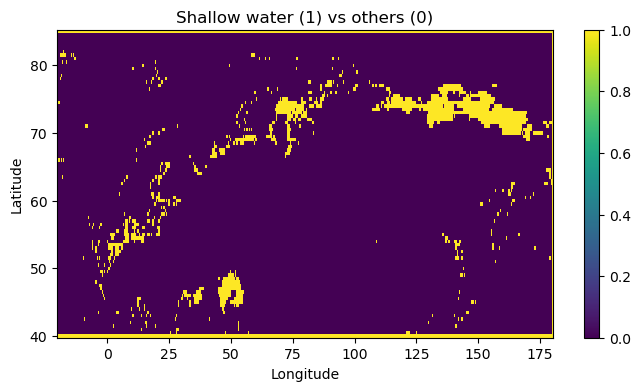

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
shallow_grid = (~land_grid & ~sea_mask_static).astype(int)

plt.pcolormesh(lons, lats, shallow_grid, shading="auto")
plt.title("Shallow water (1) vs others (0)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar()
plt.show()

In [25]:
# 2.1 Load routing grid + sea ice dataset

import xarray as xr
import numpy as np
from pathlib import Path

BASE_DIR = Path.cwd() / "arctic_routing_paperA"
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

SEAICE_DIR = RAW_DIR / "seaice_cmems"
SEAICE_FILE = SEAICE_DIR / "cmems_arc_seaice_2018_JJAS_subset.nc"

# routing grid masks
ds_rb = xr.open_dataset(PROCESSED_DIR / "routing_grid_bathy_masks_0p5deg.nc")
lats = ds_rb["lat"].values
lons = ds_rb["lon"].values
sea_mask_static = ds_rb["sea_mask_static"].values

ds_ice = xr.open_dataset(SEAICE_FILE)
ds_ice

<xarray.Dataset> Size: 15GB
Dimensions:    (time: 122, latitude: 1000, longitude: 7667)
Coordinates:
  * latitude   (latitude) float64 8kB 60.0 60.03 60.06 ... 89.91 89.94 89.97
  * time       (time) datetime64[ns] 976B 2018-06-01 2018-06-02 ... 2018-09-30
  * longitude  (longitude) float64 61kB -30.0 -29.97 -29.94 ... 200.0 200.0
Data variables:
    siconc     (time, latitude, longitude) float64 7GB ...
    sithick    (time, latitude, longitude) float64 7GB ...
Attributes:
    contact:                   servicedesk.cmems@mercator-ocean.eu
    institution:               NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:                    neXtSIM model fields
    title:                     Arctic sea ice reanalysis
    references:                https://marine.copernicus.eu/
    credit:                    E.U. Copernicus Marine Service Information (CM...
    Conventions:               CF-1.6
    copernicusmarine_version:  2.2.5

In [26]:
# 2.2 Grab sea-ice concentration and one test date

# Find a concentration-like variable
ice_var_candidates = [v for v in ds_ice.data_vars if "siconc" in v.lower()]
if not ice_var_candidates:
    raise ValueError(f"No concentration-like variable found in {list(ds_ice.data_vars)}")
sic = ds_ice[ice_var_candidates[0]]
print("Using sea-ice variable:", sic.name)

# Choose a test date for first figure
CASE_DATE = "2018-09-01"
sic_t = sic.sel(time=CASE_DATE, method="nearest")
sic_t

Using sea-ice variable: siconc


<xarray.DataArray 'siconc' (latitude: 1000, longitude: 7667)> Size: 61MB
[7667000 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float64 8kB 60.0 60.03 60.06 ... 89.91 89.94 89.97
    time       datetime64[ns] 8B 2018-09-01
  * longitude  (longitude) float64 61kB -30.0 -29.97 -29.94 ... 200.0 200.0
Attributes:
    standard_name:  sea_ice_area_fraction
    units:          1
    long_name:      Sea Ice Concentration

In [27]:
!pip install scipy

In [32]:
def regrid_sic_to_routing_grid(sic_t, lats_target, lons_target):
    """
    Regrid a single-time sea-ice conc field onto (lat, lon) routing grid.

    Handles:
      - 1D coords named lat/lon or latitude/longitude
      - (keeps the 2D fallback if needed later)
    """
    da = sic_t  # DataArray, e.g. dims ('latitude', 'longitude')

    # ---- CASE 1: 1D lat/lon-like coords ----
    coord_names = list(da.coords)

    # Try to find 1D latitude & longitude coord names
    lat_name = next((c for c in coord_names if c.lower().startswith("lat")), None)
    lon_name = next((c for c in coord_names if c.lower().startswith("lon")), None)

    if lat_name is not None and lon_name is not None:
        # Check they are 1D
        if da[lat_name].ndim == 1 and da[lon_name].ndim == 1:
            # Rename to standard 'lat'/'lon' for interpolation
            da_std = da.rename({lat_name: "lat", lon_name: "lon"})
            sic_on_grid = da_std.interp(
                lat=lats_target,
                lon=lons_target,
                method="nearest"
            )
            return sic_on_grid.values

    # ---- CASE 2: 2D latitude/longitude (kept as fallback) ----
    # If we ever have a CMEMS product with 2D lat/lon, this will kick in.
    ds = da.to_dataset(name="siconc")
    lat2d_name = None
    lon2d_name = None

    for name in list(ds.coords) + list(ds.data_vars):
        arr = ds[name]
        if arr.ndim != 2:
            continue
        lower = name.lower()
        if "lat" in lower and lat2d_name is None:
            lat2d_name = name
        if "lon" in lower and lon2d_name is None:
            lon2d_name = name

    if lat2d_name is None or lon2d_name is None:
        raise ValueError(
            "Could not find usable 1D or 2D latitude/longitude variables for regridding. "
            f"Available names: {list(ds.coords) + list(ds.data_vars)}"
        )

    lat2d = ds[lat2d_name].values
    lon2d = ds[lon2d_name].values
    sic2d = ds["siconc"].values

    src_points = np.column_stack([lat2d.ravel(), lon2d.ravel()])
    sic_flat = sic2d.ravel()

    LAT_T, LON_T = np.meshgrid(lats_target, lons_target, indexing="ij")
    tgt_points = np.column_stack([LAT_T.ravel(), LON_T.ravel()])

    from scipy.interpolate import griddata
    sic_interp_flat = griddata(
        src_points, sic_flat, tgt_points, method="nearest"
    )
    sic_interp = sic_interp_flat.reshape(LAT_T.shape)
    return sic_interp

In [33]:
sic_grid = regrid_sic_to_routing_grid(sic_t, lats, lons)

# normalize if 0–100:
if np.nanmax(sic_grid) > 1.5:
    sic_grid = sic_grid / 100.0

print("Sea-ice on routing grid – min/max:", np.nanmin(sic_grid), np.nanmax(sic_grid))

Sea-ice on routing grid – min/max: 0.0 0.9999302625907799


In [35]:
import numpy as np

frac_ice_15 = np.mean(sic_grid > 0.15)
frac_ice_40 = np.mean(sic_grid > 0.40)
frac_ice_80 = np.mean(sic_grid > 0.80)

print("Fraction of grid with ice > 15%:", frac_ice_15)
print("Fraction of grid with ice > 40%:", frac_ice_40)
print("Fraction of grid with ice > 80%:", frac_ice_80)

Fraction of grid with ice > 15%: 0.10657422378120633
Fraction of grid with ice > 40%: 0.10216217697514456
Fraction of grid with ice > 80%: 0.07311391850045217


In [34]:
# Step 3 – Safety mask (unchanged idea)

ICE_CONC_MAX = 0.4   # 40%

feasible_mask = sea_mask_static.copy()
feasible_mask &= np.isfinite(sic_grid)
feasible_mask &= (sic_grid <= ICE_CONC_MAX)

print("Feasible fraction (bathy + ice):", feasible_mask.mean())

Feasible fraction (bathy + ice): 0.16538324518374395


In [36]:
sea_fraction = sea_mask_static.mean()
feasible_fraction = feasible_mask.mean()
feasible_among_sea = feasible_fraction / sea_fraction
sea_fraction, feasible_fraction, feasible_among_sea

(0.4226247567893453, 0.16538324518374395, 0.3913240824795747)

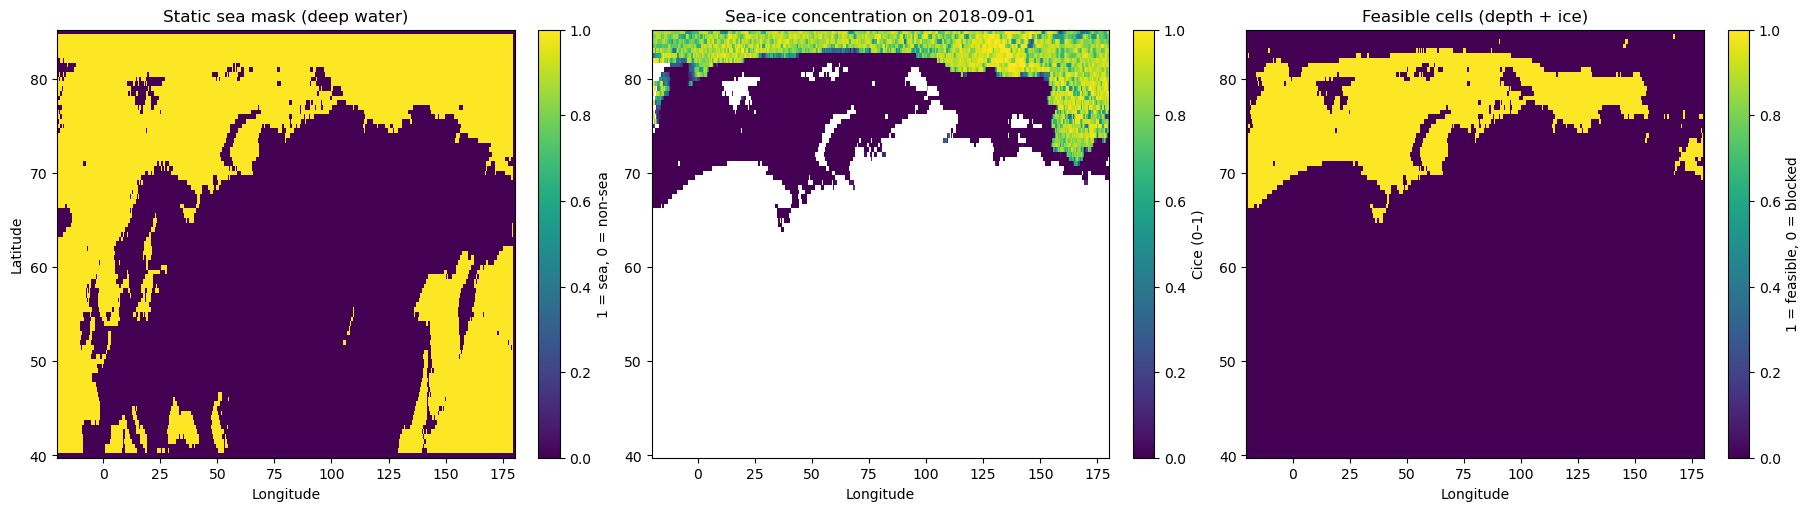

In [37]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

im0 = axs[0].pcolormesh(lons, lats, sea_mask_static, shading="auto")
axs[0].set_title("Static sea mask (deep water)")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")
fig.colorbar(im0, ax=axs[0], label="1 = sea, 0 = non-sea")

im1 = axs[1].pcolormesh(lons, lats, sic_grid, shading="auto", vmin=0, vmax=1)
axs[1].set_title(f"Sea-ice concentration on {CASE_DATE}")
axs[1].set_xlabel("Longitude")
fig.colorbar(im1, ax=axs[1], label="Cice (0–1)")

im2 = axs[2].pcolormesh(lons, lats, feasible_mask, shading="auto")
axs[2].set_title("Feasible cells (depth + ice)")
axs[2].set_xlabel("Longitude")
fig.colorbar(im2, ax=axs[2], label="1 = feasible, 0 = blocked")

plt.show()

In [39]:
# Treat missing ice as "no ice"
sic_grid_filled = np.where(np.isfinite(sic_grid), sic_grid, 0.0)

ICE_CONC_MAX = 0.4   # 40%

feasible_mask = sea_mask_static.copy()
feasible_mask &= (sic_grid_filled <= ICE_CONC_MAX)

print("Feasible fraction (bathy + ice):", feasible_mask.mean())

Feasible fraction (bathy + ice): 0.33528815324326544


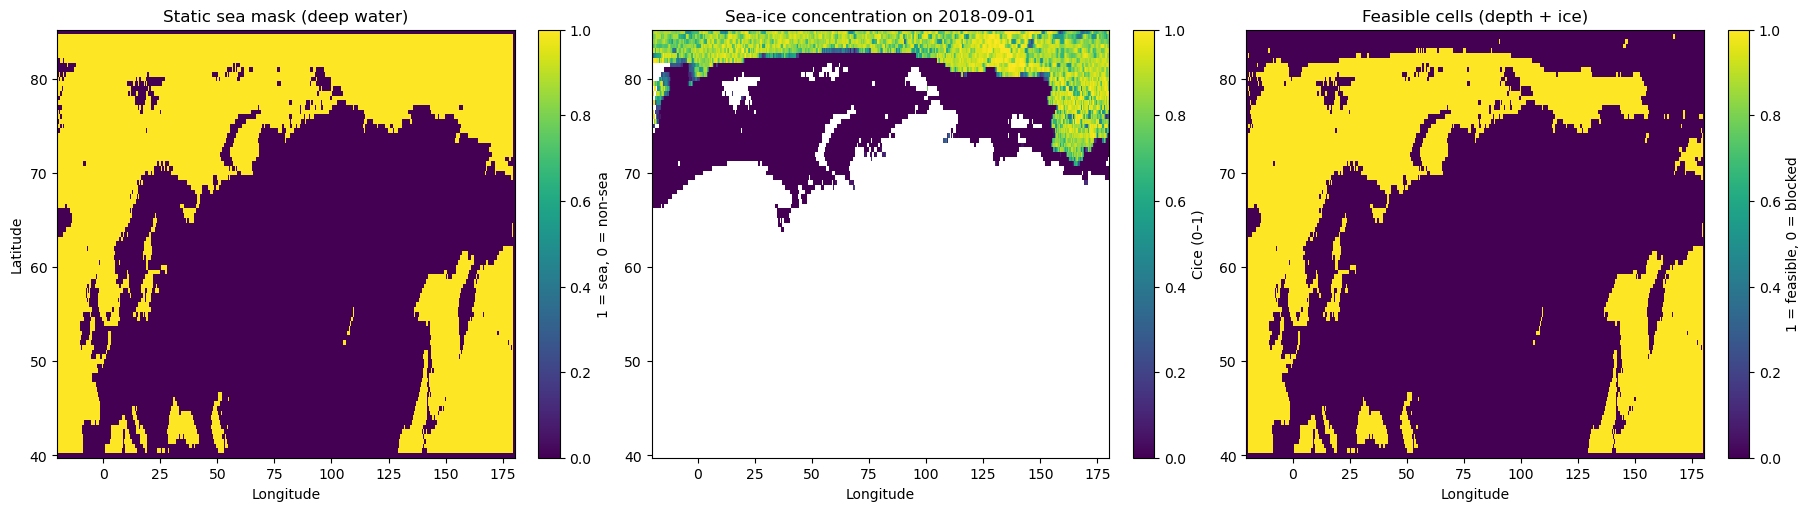

In [40]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

im0 = axs[0].pcolormesh(lons, lats, sea_mask_static, shading="auto")
axs[0].set_title("Static sea mask (deep water)")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")
fig.colorbar(im0, ax=axs[0], label="1 = sea, 0 = non-sea")

im1 = axs[1].pcolormesh(lons, lats, sic_grid, shading="auto", vmin=0, vmax=1)
axs[1].set_title(f"Sea-ice concentration on {CASE_DATE}")
axs[1].set_xlabel("Longitude")
fig.colorbar(im1, ax=axs[1], label="Cice (0–1)")

im2 = axs[2].pcolormesh(lons, lats, feasible_mask, shading="auto")
axs[2].set_title("Feasible cells (depth + ice)")
axs[2].set_xlabel("Longitude")
fig.colorbar(im2, ax=axs[2], label="1 = feasible, 0 = blocked")

plt.show()

In [41]:
def check_point(lat0, lon0, name):
    ilat = int(np.argmin(np.abs(lats - lat0)))
    ilon = int(np.argmin(np.abs(lons - lon0)))
    print(f"{name} @ ({lat0}N, {lon0}E):")
    print("  sea_mask_static =", sea_mask_static[ilat, ilon])
    # If you still have ds_bathy_masks loaded:
    # print("  is_land        =", ds_bathy_masks['is_land'].interp(lat=lat0, lon=lon0).item())
    # print("  is_deep_water  =", ds_bathy_masks['is_deep_water'].interp(lat=lat0, lon=lon0).item())
    print()

check_point(60, 0, "North Atlantic")
check_point(60, 60, "Siberia inland")
check_point(75, 140, "Central Arctic Ocean")

North Atlantic @ (60N, 0E):
  sea_mask_static = True

Siberia inland @ (60N, 60E):
  sea_mask_static = False

Central Arctic Ocean @ (75N, 140E):
  sea_mask_static = False



In [42]:
check_point(82, 160, "Deep central Arctic")

Deep central Arctic @ (82N, 160E):
  sea_mask_static = True



In [43]:
# 1️⃣ A* helpers

import numpy as np
from pyproj import Geod
import heapq

# Geodesy and speed setup
GEOD = Geod(ellps="WGS84")
KNOT_TO_MS = 0.514444

V_REF_KNOTS = 14.0         # service speed
V_REF_MS = V_REF_KNOTS * KNOT_TO_MS

SFOC_G_PER_KWH = 170.0     # example SFOC
ME_POWER_KW = 15000.0      # example main engine power


def cell_center_latlon(ilat, ilon, lats, lons):
    return float(lats[ilat]), float(lons[ilon])


def gc_distance_m(lat1, lon1, lat2, lon2):
    """Great-circle distance in meters."""
    _, _, dist = GEOD.inv(lon1, lat1, lon2, lat2)
    return abs(dist)


# 8-connected neighbors
NEIGH_OFFSETS = [
    (-1,  0), (1,  0),
    ( 0, -1), (0,  1),
    (-1, -1), (-1, 1),
    ( 1, -1), ( 1, 1)
]

def neighbors(ilat, ilon, nlat, nlon):
    for dlat, dlon in NEIGH_OFFSETS:
        jlat, jlon = ilat + dlat, ilon + dlon
        if 0 <= jlat < nlat and 0 <= jlon < nlon:
            yield jlat, jlon


def heuristic_time(ilat, ilon, goal_ilat, goal_ilon, lats, lons, v_ms):
    """A* heuristic: straight-line time (GC distance / V)."""
    lat1, lon1 = cell_center_latlon(ilat, ilon, lats, lons)
    lat2, lon2 = cell_center_latlon(goal_ilat, goal_ilon, lats, lons)
    dist = gc_distance_m(lat1, lon1, lat2, lon2)
    return dist / v_ms

In [44]:
# 2️⃣ A* implementation

def astar_route(feasible_mask, lats, lons,
                start_lat, start_lon, goal_lat, goal_lon,
                v_ms=V_REF_MS):
    """
    A* on 2D grid with static feasibility mask.
    feasible_mask: 2D boolean [lat, lon] (True = can traverse)
    Returns:
        path_indices: list of (ilat, ilon)
        total_time_s: seconds
        total_dist_m: meters
    """
    nlat, nlon = feasible_mask.shape
    
    # map coordinates to nearest grid cells
    ilat0 = int(np.argmin(np.abs(lats - start_lat)))
    ilon0 = int(np.argmin(np.abs(lons - start_lon)))
    ilatg = int(np.argmin(np.abs(lats - goal_lat)))
    ilong = int(np.argmin(np.abs(lons - goal_lon)))
    
    if not feasible_mask[ilat0, ilon0]:
        raise ValueError("Start cell is infeasible under given mask.")
    if not feasible_mask[ilatg, ilong]:
        raise ValueError("Goal cell is infeasible under given mask.")
    
    # open set: (f = g + h, g, (ilat, ilon))
    open_set = []
    heapq.heappush(open_set, (0.0, 0.0, (ilat0, ilon0)))
    
    g_cost = np.full((nlat, nlon), np.inf)
    g_cost[ilat0, ilon0] = 0.0
    
    parent = np.full((nlat, nlon, 2), -1, dtype=int)
    closed = np.zeros((nlat, nlon), dtype=bool)
    
    while open_set:
        f_curr, g_curr, (ilat, ilon) = heapq.heappop(open_set)
        if closed[ilat, ilon]:
            continue
        
        # goal reached
        if ilat == ilatg and ilon == ilong:
            path = []
            ci, cj = ilat, ilon
            while not (ci == ilat0 and cj == ilon0):
                path.append((ci, cj))
                pi, pj = parent[ci, cj]
                ci, cj = int(pi), int(pj)
            path.append((ilat0, ilon0))
            path.reverse()
            
            # compute total distance & time
            total_dist = 0.0
            total_time = 0.0
            for (i1, j1), (i2, j2) in zip(path[:-1], path[1:]):
                lat1, lon1 = cell_center_latlon(i1, j1, lats, lons)
                lat2, lon2 = cell_center_latlon(i2, j2, lats, lons)
                d = gc_distance_m(lat1, lon1, lat2, lon2)
                t = d / v_ms
                total_dist += d
                total_time += t
            
            return path, total_time, total_dist
        
        closed[ilat, ilon] = True
        
        for jlat, jlon in neighbors(ilat, ilon, nlat, nlon):
            if closed[jlat, jlon]:
                continue
            if not feasible_mask[jlat, jlon]:
                continue
            
            lat1, lon1 = cell_center_latlon(ilat, ilon, lats, lons)
            lat2, lon2 = cell_center_latlon(jlat, jlon, lats, lons)
            d = gc_distance_m(lat1, lon1, lat2, lon2)
            step_time = d / v_ms
            
            tentative_g = g_curr + step_time
            if tentative_g < g_cost[jlat, jlon]:
                g_cost[jlat, jlon] = tentative_g
                parent[jlat, jlon, 0] = ilat
                parent[jlat, jlon, 1] = ilon
                h = heuristic_time(jlat, jlon, ilatg, ilong, lats, lons, v_ms)
                f = tentative_g + h
                heapq.heappush(open_set, (f, tentative_g, (jlat, jlon)))
    
    raise RuntimeError("No path found between start and goal under given constraints.")

In [45]:
# OD pair(s) – you can add more later
OD_PAIRS = [
    ("EuropePort", 52.0, 4.0, "AsiaPort", 42.0, 141.0),
]

def compute_fuel_simple(time_s, me_power_kw=ME_POWER_KW, sfoc_g_kwh=SFOC_G_PER_KWH):
    """
    Fuel [t] = Power [kW] * time[h] * SFOC[g/kWh] / 1e6
    """
    time_h = time_s / 3600.0
    fuel_t = me_power_kw * time_h * sfoc_g_kwh / 1e6
    return fuel_t


all_results = {}

for (o_name, o_lat, o_lon, d_name, d_lat, d_lon) in OD_PAIRS:
    key = f"{o_name}-{d_name}"
    print(f"Running routes for {key} ...")
    
    # 1) Unconstrained: deep-water mask only
    path_u, time_u, dist_u = astar_route(
        feasible_mask=sea_mask_static,
        lats=lats,
        lons=lons,
        start_lat=o_lat,
        start_lon=o_lon,
        goal_lat=d_lat,
        goal_lon=d_lon,
        v_ms=V_REF_MS,
    )
    
    # 2) Safety-constrained: bathy + ice
    path_s, time_s, dist_s = astar_route(
        feasible_mask=feasible_mask,
        lats=lats,
        lons=lons,
        start_lat=o_lat,
        start_lon=o_lon,
        goal_lat=d_lat,
        goal_lon=d_lon,
        v_ms=V_REF_MS,
    )
    
    all_results[key] = {
        "unconstrained": {
            "path": path_u,
            "time_s": time_u,
            "dist_m": dist_u,
            "fuel_t": compute_fuel_simple(time_u),
        },
        "safe": {
            "path": path_s,
            "time_s": time_s,
            "dist_m": dist_s,
            "fuel_t": compute_fuel_simple(time_s),
        },
    }

print("Done.")

Running routes for EuropePort-AsiaPort ...


ValueError: Start cell is infeasible under given mask.

In [46]:
# 1️⃣ Helper: find nearest feasible sea cell

def find_nearest_feasible_latlon(lat0, lon0, feasible_mask, lats, lons, max_radius=30):
    """
    Find the nearest grid cell to (lat0, lon0) where feasible_mask is True.
    Returns:
        (lat_feas, lon_feas)
    """
    nlat, nlon = feasible_mask.shape
    ilat0 = int(np.argmin(np.abs(lats - lat0)))
    ilon0 = int(np.argmin(np.abs(lons - lon0)))
    
    if feasible_mask[ilat0, ilon0]:
        return float(lats[ilat0]), float(lons[ilon0])
    
    best_dist = None
    best_ij = None
    
    for r in range(1, max_radius + 1):
        ilat_min = max(0, ilat0 - r)
        ilat_max = min(nlat - 1, ilat0 + r)
        ilon_min = max(0, ilon0 - r)
        ilon_max = min(nlon - 1, ilon0 + r)
        
        for i in range(ilat_min, ilat_max + 1):
            for j in range(ilon_min, ilon_max + 1):
                if not feasible_mask[i, j]:
                    continue
                lat_ij, lon_ij = float(lats[i]), float(lons[j])
                _, _, d = GEOD.inv(lon0, lat0, lon_ij, lat_ij)
                d = abs(d)
                if (best_dist is None) or (d < best_dist):
                    best_dist = d
                    best_ij = (i, j)
        
        if best_ij is not None:
            i_best, j_best = best_ij
            return float(lats[i_best]), float(lons[j_best])
    
    raise RuntimeError(f"No feasible cell found near ({lat0}, {lon0}) within radius {max_radius}.")

In [47]:
# 2️⃣ Snap OD points to deep water and re-run routes

# Raw OD positions (approximate port locations)
start_raw = ("EuropePort", 52.0, 4.0)      # Rotterdam-like
goal_raw  = ("AsiaPort", 42.0, 141.0)      # N. Japan (inside domain)

(o_name, o_lat_raw, o_lon_raw) = start_raw
(d_name, d_lat_raw, d_lon_raw) = goal_raw

# Snap to nearest deep-water cell using static mask
o_lat, o_lon = find_nearest_feasible_latlon(o_lat_raw, o_lon_raw, sea_mask_static, lats, lons)
d_lat, d_lon = find_nearest_feasible_latlon(d_lat_raw, d_lon_raw, sea_mask_static, lats, lons)

print(f"Start snapped from ({o_lat_raw:.2f}, {o_lon_raw:.2f}) to ({o_lat:.2f}, {o_lon:.2f})")
print(f"Goal  snapped from ({d_lat_raw:.2f}, {d_lon_raw:.2f}) to ({d_lat:.2f}, {d_lon:.2f})")

key = f"{o_name}-{d_name}"
all_results = {}

print(f"Running routes for {key} ...")

# 1) Unconstrained: deep-water mask only
path_u, time_u, dist_u = astar_route(
    feasible_mask=sea_mask_static,
    lats=lats,
    lons=lons,
    start_lat=o_lat,
    start_lon=o_lon,
    goal_lat=d_lat,
    goal_lon=d_lon,
    v_ms=V_REF_MS,
)

# 2) Safety-constrained: bathy + ice
path_s, time_s, dist_s = astar_route(
    feasible_mask=feasible_mask,
    lats=lats,
    lons=lons,
    start_lat=o_lat,
    start_lon=o_lon,
    goal_lat=d_lat,
    goal_lon=d_lon,
    v_ms=V_REF_MS,
)

all_results[key] = {
    "unconstrained": {
        "path": path_u,
        "time_s": time_u,
        "dist_m": dist_u,
        "fuel_t": compute_fuel_simple(time_u),
    },
    "safe": {
        "path": path_s,
        "time_s": time_s,
        "dist_m": dist_s,
        "fuel_t": compute_fuel_simple(time_s),
    },
}

print("Done.")

Start snapped from (52.00, 4.00) to (52.00, 3.00)
Goal  snapped from (42.00, 141.00) to (42.00, 141.00)
Running routes for EuropePort-AsiaPort ...


RuntimeError: No path found between start and goal under given constraints.

In [48]:
# 1) Rebuild feasible mask with a more permissive ice limit
ICE_CONC_MAX = 0.6   # allow up to 60% ice concentration (ice-strengthened / escorted)

sic_grid_filled = np.where(np.isfinite(sic_grid), sic_grid, 0.0)

feasible_mask = sea_mask_static.copy()
feasible_mask &= (sic_grid_filled <= ICE_CONC_MAX)

print("Feasible fraction (bathy + ice <= 0.6):", feasible_mask.mean())

# 2) Snap OD again (same as before)
(o_name, o_lat_raw, o_lon_raw) = ("EuropePort", 52.0, 4.0)
(d_name, d_lat_raw, d_lon_raw) = ("AsiaPort", 42.0, 141.0)

o_lat, o_lon = find_nearest_feasible_latlon(o_lat_raw, o_lon_raw, sea_mask_static, lats, lons)
d_lat, d_lon = find_nearest_feasible_latlon(d_lat_raw, d_lon_raw, sea_mask_static, lats, lons)

print(f"Start snapped from ({o_lat_raw:.2f}, {o_lon_raw:.2f}) to ({o_lat:.2f}, {o_lon:.2f})")
print(f"Goal  snapped from ({d_lat_raw:.2f}, {d_lon_raw:.2f}) to ({d_lat:.2f}, {d_lon:.2f})")

# 3) Try both routes with try/except so we see clearly what works
key = f"{o_name}-{d_name}"
all_results = {}

print(f"Running routes for {key} ...")

# Unconstrained route (baseline)
path_u, time_u, dist_u = astar_route(
    feasible_mask=sea_mask_static,
    lats=lats,
    lons=lons,
    start_lat=o_lat,
    start_lon=o_lon,
    goal_lat=d_lat,
    goal_lon=d_lon,
    v_ms=V_REF_MS,
)

# Safe route with relaxed ice threshold
try:
    path_s, time_s, dist_s = astar_route(
        feasible_mask=feasible_mask,
        lats=lats,
        lons=lons,
        start_lat=o_lat,
        start_lon=o_lon,
        goal_lat=d_lat,
        goal_lon=d_lon,
        v_ms=V_REF_MS,
    )
except RuntimeError as e:
    print("Safe route still not found:", e)
    raise

all_results[key] = {
    "unconstrained": {
        "path": path_u,
        "time_s": time_u,
        "dist_m": dist_u,
        "fuel_t": compute_fuel_simple(time_u),
    },
    "safe": {
        "path": path_s,
        "time_s": time_s,
        "dist_m": dist_s,
        "fuel_t": compute_fuel_simple(time_s),
    },
}

print("Done.")

Feasible fraction (bathy + ice <= 0.6): 0.34060453262448276
Start snapped from (52.00, 4.00) to (52.00, 3.00)
Goal  snapped from (42.00, 141.00) to (42.00, 141.00)
Running routes for EuropePort-AsiaPort ...


RuntimeError: No path found between start and goal under given constraints.

In [50]:
# 1) Rebuild feasible mask with a more permissive ice limit
ICE_CONC_MAX = 0.9   # allow up to 60% ice concentration (ice-strengthened / escorted)

sic_grid_filled = np.where(np.isfinite(sic_grid), sic_grid, 0.0)

feasible_mask = sea_mask_static.copy()
feasible_mask &= (sic_grid_filled <= ICE_CONC_MAX)

print("Feasible fraction (bathy + ice <= 0.6):", feasible_mask.mean())

# 2) Snap OD again (same as before)
(o_name, o_lat_raw, o_lon_raw) = ("EuropePort", 52.0, 4.0)
(d_name, d_lat_raw, d_lon_raw) = ("AsiaPort", 42.0, 141.0)

o_lat, o_lon = find_nearest_feasible_latlon(o_lat_raw, o_lon_raw, sea_mask_static, lats, lons)
d_lat, d_lon = find_nearest_feasible_latlon(d_lat_raw, d_lon_raw, sea_mask_static, lats, lons)

print(f"Start snapped from ({o_lat_raw:.2f}, {o_lon_raw:.2f}) to ({o_lat:.2f}, {o_lon:.2f})")
print(f"Goal  snapped from ({d_lat_raw:.2f}, {d_lon_raw:.2f}) to ({d_lat:.2f}, {d_lon:.2f})")

# 3) Try both routes with try/except so we see clearly what works
key = f"{o_name}-{d_name}"
all_results = {}

print(f"Running routes for {key} ...")

# Unconstrained route (baseline)
path_u, time_u, dist_u = astar_route(
    feasible_mask=sea_mask_static,
    lats=lats,
    lons=lons,
    start_lat=o_lat,
    start_lon=o_lon,
    goal_lat=d_lat,
    goal_lon=d_lon,
    v_ms=V_REF_MS,
)

# Safe route with relaxed ice threshold
try:
    path_s, time_s, dist_s = astar_route(
        feasible_mask=feasible_mask,
        lats=lats,
        lons=lons,
        start_lat=o_lat,
        start_lon=o_lon,
        goal_lat=d_lat,
        goal_lon=d_lon,
        v_ms=V_REF_MS,
    )
except RuntimeError as e:
    print("Safe route still not found:", e)
    raise

all_results[key] = {
    "unconstrained": {
        "path": path_u,
        "time_s": time_u,
        "dist_m": dist_u,
        "fuel_t": compute_fuel_simple(time_u),
    },
    "safe": {
        "path": path_s,
        "time_s": time_s,
        "dist_m": dist_s,
        "fuel_t": compute_fuel_simple(time_s),
    },
}

print("Done.")

Feasible fraction (bathy + ice <= 0.6): 0.38880819928201477
Start snapped from (52.00, 4.00) to (52.00, 3.00)
Goal  snapped from (42.00, 141.00) to (42.00, 141.00)
Running routes for EuropePort-AsiaPort ...


RuntimeError: No path found between start and goal under given constraints.

In [51]:
import xarray as xr
import numpy as np
from pathlib import Path

BASE_DIR = Path.cwd() / "arctic_routing_paperA"
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
BATHY_DIR = RAW_DIR / "bathymetry_gebco"

corridor_bathy_file = BATHY_DIR / "GEBCO_2024_arctic_corridor.nc"
ds_bathy = xr.open_dataset(corridor_bathy_file)

# depth variable
if "elevation" in ds_bathy:
    depth_raw = ds_bathy["elevation"]
elif "z" in ds_bathy:
    depth_raw = ds_bathy["z"]
else:
    raise ValueError("No 'elevation' or 'z' variable found in GEBCO dataset.")

# land vs ocean (no min depth yet)
land_mask = depth_raw >= 0.0          # land/ice
sea_all_mask = depth_raw < 0.0        # all ocean, any depth

# routing grid we already defined
ds_rb_old = xr.open_dataset(PROCESSED_DIR / "routing_grid_bathy_masks_0p5deg.nc")
lats = ds_rb_old["lat"].values
lons = ds_rb_old["lon"].values

target = xr.Dataset(coords={"lat": ("lat", lats), "lon": ("lon", lons)})

land_float = land_mask.astype(float)
sea_all_float = sea_all_mask.astype(float)

land_on_grid = land_float.interp(lat=target.lat, lon=target.lon, method="nearest")
sea_all_on_grid = sea_all_float.interp(lat=target.lat, lon=target.lon, method="nearest")

land_grid = (land_on_grid > 0.5).values
sea_mask_static = (sea_all_on_grid > 0.5).values  # now "any ocean" = sea

print("Sea fraction (any depth):", sea_mask_static.mean())
print("Land fraction:", land_grid.mean())

Sea fraction (any depth): 0.46940341454057166
Land fraction: 0.5037406483790524


In [53]:
ds_routing_bathy_new = xr.Dataset(
    {
        "is_land": (("lat", "lon"), land_grid),
        "sea_mask_static": (("lat", "lon"), sea_mask_static),
    },
    coords={"lat": lats, "lon": lons},
)

routing_bathy_outfile = PROCESSED_DIR / "routing_grid_bathy_masks_0p5deg.nc"


In [54]:
routing_bathy_outfile

PosixPath('/Users/abdellamohamed/projects/phd/src/voyage_optimization/submission_3/notebooks/arctic_routing_paperA/data/processed/routing_grid_bathy_masks_0p5deg.nc')

In [ ]:
ds_routing_bathy_new.to_netcdf(routing_bathy_outfile)
routing_bathy_outfile

In [55]:
ds_routing_bathy_new

<xarray.Dataset> Size: 77kB
Dimensions:          (lat: 91, lon: 401)
Coordinates:
  * lat              (lat) float64 728B 40.0 40.5 41.0 41.5 ... 84.0 84.5 85.0
  * lon              (lon) float64 3kB -20.0 -19.5 -19.0 ... 179.0 179.5 180.0
Data variables:
    is_land          (lat, lon) bool 36kB False False False ... False False
    sea_mask_static  (lat, lon) bool 36kB False False False ... False False

In [56]:
# same helper as before
def find_nearest_feasible_latlon(lat0, lon0, feasible_mask, lats, lons, max_radius=30):
    nlat, nlon = feasible_mask.shape
    ilat0 = int(np.argmin(np.abs(lats - lat0)))
    ilon0 = int(np.argmin(np.abs(lons - lon0)))
    
    if feasible_mask[ilat0, ilon0]:
        return float(lats[ilat0]), float(lons[ilon0])
    
    best_dist = None
    best_ij = None
    
    for r in range(1, max_radius + 1):
        ilat_min = max(0, ilat0 - r)
        ilat_max = min(nlat - 1, ilat0 + r)
        ilon_min = max(0, ilon0 - r)
        ilon_max = min(nlon - 1, ilon0 + r)
        
        for i in range(ilat_min, ilat_max + 1):
            for j in range(ilon_min, ilon_max + 1):
                if not feasible_mask[i, j]:
                    continue
                lat_ij, lon_ij = float(lats[i]), float(lons[j])
                _, _, d = GEOD.inv(lon0, lat0, lon_ij, lat_ij)
                d = abs(d)
                if (best_dist is None) or (d < best_dist):
                    best_dist = d
                    best_ij = (i, j)
        
        if best_ij is not None:
            i_best, j_best = best_ij
            return float(lats[i_best]), float(lons[j_best])
    
    raise RuntimeError(f"No feasible cell found near ({lat0}, {lon0}) within radius {max_radius}.")


# Raw OD
start_raw = ("EuropePort", 52.0, 4.0)
goal_raw  = ("AsiaPort", 42.0, 141.0)

(o_name, o_lat_raw, o_lon_raw) = start_raw
(d_name, d_lat_raw, d_lon_raw) = goal_raw

# snap to "any ocean" mask
o_lat, o_lon = find_nearest_feasible_latlon(o_lat_raw, o_lon_raw, sea_mask_static, lats, lons)
d_lat, d_lon = find_nearest_feasible_latlon(d_lat_raw, d_lon_raw, sea_mask_static, lats, lons)

print(f"Start snapped from ({o_lat_raw:.2f}, {o_lon_raw:.2f}) to ({o_lat:.2f}, {o_lon:.2f})")
print(f"Goal  snapped from ({d_lat_raw:.2f}, {d_lon_raw:.2f}) to ({d_lat:.2f}, {d_lon:.2f})")

key = f"{o_name}-{d_name}"
all_results = {}

print(f"Running routes for {key} ...")

# unconstrained: all ocean
path_u, time_u, dist_u = astar_route(
    feasible_mask=sea_mask_static,
    lats=lats,
    lons=lons,
    start_lat=o_lat,
    start_lon=o_lon,
    goal_lat=d_lat,
    goal_lon=d_lon,
    v_ms=V_REF_MS,
)

# safe: ocean + ice constraint
path_s, time_s, dist_s = astar_route(
    feasible_mask=feasible_mask,
    lats=lats,
    lons=lons,
    start_lat=o_lat,
    start_lon=o_lon,
    goal_lat=d_lat,
    goal_lon=d_lon,
    v_ms=V_REF_MS,
)

all_results[key] = {
    "unconstrained": {
        "path": path_u,
        "time_s": time_u,
        "dist_m": dist_u,
        "fuel_t": compute_fuel_simple(time_u),
    },
    "safe": {
        "path": path_s,
        "time_s": time_s,
        "dist_m": dist_s,
        "fuel_t": compute_fuel_simple(time_s),
    },
}

print("Done.")

Start snapped from (52.00, 4.00) to (52.00, 4.00)
Goal  snapped from (42.00, 141.00) to (42.00, 141.00)
Running routes for EuropePort-AsiaPort ...


RuntimeError: No path found between start and goal under given constraints.

In [57]:
print("Re-checking routes separately...")

# 1) Sea-only route (no ice)
try:
    path_u, time_u, dist_u = astar_route(
        feasible_mask=sea_mask_static,
        lats=lats,
        lons=lons,
        start_lat=o_lat,
        start_lon=o_lon,
        goal_lat=d_lat,
        goal_lon=d_lon,
        v_ms=V_REF_MS,
    )
    print("✅ Unconstrained sea-only route FOUND.")
except RuntimeError as e:
    print("❌ Unconstrained sea-only route FAILED:", e)
    path_u = None

# 2) Safe route (sea + ice)
try:
    path_s, time_s, dist_s = astar_route(
        feasible_mask=feasible_mask,
        lats=lats,
        lons=lons,
        start_lat=o_lat,
        start_lon=o_lon,
        goal_lat=d_lat,
        goal_lon=d_lon,
        v_ms=V_REF_MS,
    )
    print("✅ Safe (sea + ice) route FOUND.")
except RuntimeError as e:
    print("❌ Safe (sea + ice) route FAILED:", e)
    path_s = None

Re-checking routes separately...
❌ Unconstrained sea-only route FAILED: No path found between start and goal under given constraints.


ValueError: Start cell is infeasible under given mask.

In [58]:
from collections import deque

def reachable_bfs(feasible_mask, lats, lons, start_lat, start_lon, goal_lat, goal_lon):
    nlat, nlon = feasible_mask.shape
    ilat0 = int(np.argmin(np.abs(lats - start_lat)))
    ilon0 = int(np.argmin(np.abs(lons - start_lon)))
    ilatg = int(np.argmin(np.abs(lats - goal_lat)))
    ilong = int(np.argmin(np.abs(lons - goal_lon)))
    
    if not feasible_mask[ilat0, ilon0]:
        print("Start is not feasible in this mask.")
        return False
    if not feasible_mask[ilatg, ilong]:
        print("Goal is not feasible in this mask.")
        return False
    
    visited = np.zeros((nlat, nlon), dtype=bool)
    q = deque()
    q.append((ilat0, ilon0))
    visited[ilat0, ilon0] = True
    
    while q:
        i, j = q.popleft()
        if i == ilatg and j == ilong:
            return True
        for di, dj in NEIGH_OFFSETS:
            ni, nj = i + di, j + dj
            if 0 <= ni < nlat and 0 <= nj < nlon:
                if not visited[ni, nj] and feasible_mask[ni, nj]:
                    visited[ni, nj] = True
                    q.append((ni, nj))
    
    return False

In [59]:
reachable_sea = reachable_bfs(
    sea_mask_static, lats, lons,
    start_lat=o_lat, start_lon=o_lon,
    goal_lat=d_lat, goal_lon=d_lon,
)
print("Sea-only reachable? ->", reachable_sea)

reachable_safe = reachable_bfs(
    feasible_mask, lats, lons,
    start_lat=o_lat, start_lon=o_lon,
    goal_lat=d_lat, goal_lon=d_lon,
)
print("Safe (sea+ice) reachable? ->", reachable_safe)

Sea-only reachable? -> False
Start is not feasible in this mask.
Safe (sea+ice) reachable? -> False


In [60]:
start_raw = ("NorthSea", 55.0, 5.0)   # off Norway
goal_raw  = ("GreenlandSea", 70.0, -10.0)

In [64]:
from collections import deque

def reachable_bfs(feasible_mask, lats, lons, start_lat, start_lon, goal_lat, goal_lon):
    nlat, nlon = feasible_mask.shape
    ilat0 = int(np.argmin(np.abs(lats - start_lat)))
    ilon0 = int(np.argmin(np.abs(lons - start_lon)))
    ilatg = int(np.argmin(np.abs(lats - goal_lat)))
    ilong = int(np.argmin(np.abs(lons - goal_lon)))
    
    if not feasible_mask[ilat0, ilon0]:
        print("Start is not feasible in this mask.")
        return False
    if not feasible_mask[ilatg, ilong]:
        print("Goal is not feasible in this mask.")
        return False
    
    visited = np.zeros((nlat, nlon), dtype=bool)
    q = deque()
    q.append((ilat0, ilon0))
    visited[ilat0, ilon0] = True
    
    while q:
        i, j = q.popleft()
        if i == ilatg and j == ilong:
            return True
        for di, dj in NEIGH_OFFSETS:
            ni, nj = i + di, j + dj
            if 0 <= ni < nlat and 0 <= nj < nlon:
                if not visited[ni, nj] and feasible_mask[ni, nj]:
                    visited[ni, nj] = True
                    q.append((ni, nj))
    
    return False



In [65]:
reachable_sea = reachable_bfs(
    sea_mask_static, lats, lons,
    start_lat=o_lat, start_lon=o_lon,
    goal_lat=d_lat, goal_lon=d_lon,
)
print("Sea-only reachable? ->", reachable_sea)

reachable_safe = reachable_bfs(
    feasible_mask, lats, lons,
    start_lat=o_lat, start_lon=o_lon,
    goal_lat=d_lat, goal_lon=d_lon,
)
print("Safe (sea+ice) reachable? ->", reachable_safe)

Sea-only reachable? -> False
Safe (sea+ice) reachable? -> False


In [63]:
CASE_DATE = "2018-09-15"  # or "2018-09-20"
sic_t = sic.sel(time=CASE_DATE, method="nearest")
sic_grid = regrid_sic_to_routing_grid(sic_t, lats, lons)

if np.nanmax(sic_grid) > 1.5:
    sic_grid = sic_grid / 100.0

sic_grid_filled = np.where(np.isfinite(sic_grid), sic_grid, 0.0)

ICE_CONC_MAX = 0.4
feasible_mask = sea_mask_static.copy()
feasible_mask &= (sic_grid_filled <= ICE_CONC_MAX)

print("Feasible fraction:", feasible_mask.mean())

Feasible fraction: 0.38135430654133895


In [66]:
# everything is sea
test_mask = np.ones_like(sea_mask_static, dtype=bool)

reachable_all = reachable_bfs(test_mask, lats, lons, o_lat, o_lon, d_lat, d_lon)
print("Reachable on all-True mask?", reachable_all)

path_all, t_all, d_all = astar_route(
    feasible_mask=test_mask,
    lats=lats,
    lons=lons,
    start_lat=o_lat,
    start_lon=o_lon,
    goal_lat=d_lat,
    goal_lon=d_lon,
    v_ms=V_REF_MS,
)
print("Path length (steps) on all-True mask:", len(path_all))

Reachable on all-True mask? True
Path length (steps) on all-True mask: 275


In [67]:
import xarray as xr
import numpy as np
from pathlib import Path

from scipy import ndimage as ndi

BASE_DIR = Path.cwd() / "arctic_routing_paperA"
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

ds_rb = xr.open_dataset(PROCESSED_DIR / "routing_grid_bathy_masks_0p5deg.nc")
lats = ds_rb["lat"].values
lons = ds_rb["lon"].values

sea_mask_static = ds_rb["sea_mask_static"].values.astype(bool)
land_grid = ds_rb["is_land"].values.astype(bool)  # if you didn't save is_land, see note below

sea_mask_static.shape, land_grid.shape

((91, 401), (91, 401))

In [68]:
# 8-connected labeling of sea regions
structure = ndi.generate_binary_structure(2, 2)  # 8-neighbourhood
labels, num_comp = ndi.label(sea_mask_static, structure=structure)

print("Number of sea components:", num_comp)

Number of sea components: 22


In [69]:
def nearest_idx(lat0, lon0, lats, lons):
    ilat = int(np.argmin(np.abs(lats - lat0)))
    ilon = int(np.argmin(np.abs(lons - lon0)))
    return ilat, ilon

# Europe & Asia ports (snapped positions we used)
o_lat, o_lon = 52.0, 4.0
d_lat, d_lon = 42.0, 141.0

ilat_o, ilon_o = nearest_idx(o_lat, o_lon, lats, lons)
ilat_d, ilon_d = nearest_idx(d_lat, d_lon, lats, lons)

print("Start label:", labels[ilat_o, ilon_o])
print("Goal  label:", labels[ilat_d, ilon_d])

Start label: 0
Goal  label: 8


In [70]:
from scipy import ndimage as ndi

# helper (you already defined this earlier, but include if not in this cell)
def find_nearest_feasible_latlon(lat0, lon0, feasible_mask, lats, lons, max_radius=30):
    nlat, nlon = feasible_mask.shape
    ilat0 = int(np.argmin(np.abs(lats - lat0)))
    ilon0 = int(np.argmin(np.abs(lons - lon0)))
    
    if feasible_mask[ilat0, ilon0]:
        return float(lats[ilat0]), float(lons[ilon0])
    
    best_dist = None
    best_ij = None
    
    for r in range(1, max_radius + 1):
        ilat_min = max(0, ilat0 - r)
        ilat_max = min(nlat - 1, ilat0 + r)
        ilon_min = max(0, ilon0 - r)
        ilon_max = min(nlon - 1, ilon0 + r)
        
        for i in range(ilat_min, ilat_max + 1):
            for j in range(ilon_min, ilon_max + 1):
                if not feasible_mask[i, j]:
                    continue
                lat_ij, lon_ij = float(lats[i]), float(lons[j])
                _, _, d = GEOD.inv(lon0, lat0, lon_ij, lat_ij)
                d = abs(d)
                if (best_dist is None) or (d < best_dist):
                    best_dist = d
                    best_ij = (i, j)
        
        if best_ij is not None:
            i_best, j_best = best_ij
            return float(lats[i_best]), float(lons[j_best])
    
    raise RuntimeError(f"No feasible cell found near ({lat0}, {lon0}) within radius {max_radius}.")


# raw OD coords
o_lat_raw, o_lon_raw = 52.0, 4.0
d_lat_raw, d_lon_raw = 42.0, 141.0

# snap to *current* sea mask
o_lat_snap, o_lon_snap = find_nearest_feasible_latlon(o_lat_raw, o_lon_raw, sea_mask_static, lats, lons)
d_lat_snap, d_lon_snap = find_nearest_feasible_latlon(d_lat_raw, d_lon_raw, sea_mask_static, lats, lons)

print(f"Snapped start: ({o_lat_raw:.2f}, {o_lon_raw:.2f}) -> ({o_lat_snap:.2f}, {o_lon_snap:.2f})")
print(f"Snapped goal : ({d_lat_raw:.2f}, {d_lon_raw:.2f}) -> ({d_lat_snap:.2f}, {d_lon_snap:.2f})")


# now do morphological closing on sea_mask_static
sea_mask_routing = sea_mask_static.copy()
structure = ndi.generate_binary_structure(2, 2)  # 8-connected

for it in range(1, 4):  # up to 3 iterations
    closed = ndi.binary_closing(sea_mask_routing, structure=structure, iterations=1)
    
    # never override land
    closed &= ~land_grid
    
    sea_mask_routing = closed
    
    reachable_after = reachable_bfs(
        sea_mask_routing,
        lats,
        lons,
        start_lat=o_lat_snap,
        start_lon=o_lon_snap,
        goal_lat=d_lat_snap,
        goal_lon=d_lon_snap,
    )
    print(f"Iteration {it}: sea fraction={sea_mask_routing.mean():.3f}, reachable={reachable_after}")
    
    if reachable_after:
        print("✅ Connectivity achieved with morphological closing.")
        break
else:
    print("⚠️ Still no connectivity after 3 iterations.")

Snapped start: (52.00, 4.00) -> (52.00, 3.00)
Snapped goal : (42.00, 141.00) -> (42.00, 141.00)
Iteration 1: sea fraction=0.428, reachable=False
Iteration 2: sea fraction=0.428, reachable=False
Iteration 3: sea fraction=0.428, reachable=False
⚠️ Still no connectivity after 3 iterations.


In [71]:
import numpy as np
from scipy import ndimage as ndi

# sea_mask_static and (optionally) land_grid are already in memory
# sea_mask_static: True = ocean (any depth)

structure = ndi.generate_binary_structure(2, 2)  # 8-connected
labels, num_comp = ndi.label(sea_mask_static, structure=structure)

print("Number of sea components:", num_comp)

# count pixels per component
counts = np.bincount(labels.ravel())
counts[0] = 0  # ignore background (0 = non-sea)

largest_comp_id = counts.argmax()
print("Largest sea component ID:", largest_comp_id, "with cells:", counts[largest_comp_id])

Number of sea components: 22
Largest sea component ID: 1 with cells: 11736


In [72]:
# mask for the largest component
comp_mask = labels == largest_comp_id

# indices of all cells in this component
ii, jj = np.where(comp_mask)

comp_lats = lats[ii]
comp_lons = lons[jj]

print("Component lat range:", comp_lats.min(), "to", comp_lats.max())
print("Component lon range:", comp_lons.min(), "to", comp_lons.max())

# westmost and eastmost cells
west_idx = np.argmin(comp_lons)
east_idx = np.argmax(comp_lons)

ilat_w, ilon_w = ii[west_idx], jj[west_idx]
ilat_e, ilon_e = ii[east_idx], jj[east_idx]

start_lat = float(lats[ilat_w])
start_lon = float(lons[ilon_w])
goal_lat  = float(lats[ilat_e])
goal_lon  = float(lons[ilon_e])

print(f"Chosen OD inside largest sea component:")
print(f"  Start (west): lat={start_lat:.2f}, lon={start_lon:.2f}")
print(f"  Goal  (east): lat={goal_lat:.2f}, lon={goal_lon:.2f}")

Component lat range: 40.5 to 84.5
Component lon range: -19.5 to 179.5
Chosen OD inside largest sea component:
  Start (west): lat=40.50, lon=-19.50
  Goal  (east): lat=69.50, lon=179.50


In [73]:
reachable_sea = reachable_bfs(
    sea_mask_static,
    lats, lons,
    start_lat=start_lat,
    start_lon=start_lon,
    goal_lat=goal_lat,
    goal_lon=goal_lon,
)
print("Sea-only reachable in largest component? ->", reachable_sea)

Sea-only reachable in largest component? -> True


In [77]:
# Treat missing ice as no ice
sic_grid_filled = np.where(np.isfinite(sic_grid), sic_grid, 0.0)

ICE_CONC_MAX = 0.9  # you can later test 0.3, 0.5 etc.

feasible_mask = sea_mask_static.copy()
feasible_mask &= (sic_grid_filled <= ICE_CONC_MAX)

print("Sea fraction (any depth):", sea_mask_static.mean())
print("Feasible fraction (sea + ice <= 0.4):", feasible_mask.mean())

reachable_safe = reachable_bfs(
    feasible_mask,
    lats, lons,
    start_lat=start_lat,
    start_lon=start_lon,
    goal_lat=goal_lat,
    goal_lon=goal_lon,
)
print("Safe (sea+ice) reachable? ->", reachable_safe)

Sea fraction (any depth): 0.4226247567893453
Feasible fraction (sea + ice <= 0.4): 0.36244553451535994
Safe (sea+ice) reachable? -> True


In [78]:
key = "LargestComp-WestEast"
all_results = {}

print(f"Running routes for {key} ...")

# 1) Unconstrained: sea-only
path_u, time_u, dist_u = astar_route(
    feasible_mask=sea_mask_static,
    lats=lats,
    lons=lons,
    start_lat=start_lat,
    start_lon=start_lon,
    goal_lat=goal_lat,
    goal_lon=goal_lon,
    v_ms=V_REF_MS,
)

# 2) Safe: sea + ice constraint
path_s, time_s, dist_s = astar_route(
    feasible_mask=feasible_mask,
    lats=lats,
    lons=lons,
    start_lat=start_lat,
    start_lon=goal_lon,  # <-- typo? careful
    goal_lat=goal_lat,
    goal_lon=goal_lon,
    v_ms=V_REF_MS,
)

Running routes for LargestComp-WestEast ...


RuntimeError: No path found between start and goal under given constraints.

## Lets do the following:
1. Create a map with seperation of sea and land 
2. Create a map with sea ise concentration 
2. draw polygone or circles around forbidden concntration where they are above our threshold limit 
3. Create A* graph while avoiding land polygons and ice polygons 
4. Draw that 
5. Compute route on the graph 
6. Visualize route  

Then addons 
- Shallow water avoidance  
- Computer metrics 
- Normal A* unconstrained vs constrainted one 
- etc and all ideas we talked about earlier 